# 02. Preprocessing (전처리) - 형태소 분석 버전
### 텍스트 정제 → 형태소 분석(KoNLPy) → TF-IDF 변환 → 학습/테스트 분리
---

## 0. 라이브러리 불러오기

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from konlpy.tag import Okt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import save_npz

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로딩 완료 ✅')

라이브러리 로딩 완료 ✅


---
## 1. 데이터 로딩

In [12]:
df = pd.read_csv('../data/reviews_eda.csv', encoding='utf-8-sig')

print(f'데이터 로딩 완료 ✅')
print(f'총 데이터 수 : {len(df):,}개')
df.head()

데이터 로딩 완료 ✅
총 데이터 수 : 200,000개


,score,content,label,content_len
0,5,배공빠르고 굿,1,7
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,29
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,1,68
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,0,136
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1,33


---
## 2. 텍스트 정제
> 특수문자 제거, 공백 정리

In [13]:
def clean_text(text):
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', ' ', str(text))
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

df['content_clean'] = df['content'].apply(clean_text)

# 5글자 미만 제거
before = len(df)
df = df[df['content_clean'].str.len() >= 5].reset_index(drop=True)
after = len(df)

print(f'정제 전 : {before:,}개')
print(f'정제 후 : {after:,}개')
print(f'제거된 행 : {before - after:,}개')

정제 전 : 200,000개
정제 후 : 199,191개
제거된 행 : 809개


---
## 3. 형태소 분석 (KoNLPy - Okt)
> 명사, 형용사, 동사만 추출

```
기존 방식  : "배송이 늦었지만 좋아요" → ["배송이", "늦었지만", "좋아요"]
형태소 분석 : "배송이 늦었지만 좋아요" → ["배송", "늦다", "좋다"]

좋아요 / 좋네요 / 좋습니다 / 좋고  →  전부 "좋다" 로 통합
```

⚠️ **20만개 데이터 처리 시간이 오래 걸릴 수 있습니다 (30분 ~ 1시간)**

In [14]:
okt = Okt()

def tokenize(text):
    # norm=True  : 정규화 (ㅋㅋㅋ → ㅋ)
    # stem=True  : 어간 추출 (좋아요 → 좋다, 늦었지만 → 늦다)
    tokens = okt.pos(text, norm=True, stem=True)

    # 명사, 형용사, 동사만 추출
    result = [word for word, pos in tokens
              if pos in ['Noun', 'Adjective', 'Verb']]
    return ' '.join(result)

# 샘플 5개로 먼저 테스트
print('=== 형태소 분석 샘플 테스트 ===')
for text in df['content_clean'].head(5):
    print(f'[원문] {text}')
    print(f'[분석] {tokenize(text)}')
    print()

=== 형태소 분석 샘플 테스트 ===
[원문] 배공빠르고 굿
[분석] 배공 빠르다 굿

[원문] 택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
[분석] 택배 엉망 용 집 밑 층 말 놔두다

[원문] 아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성하긴 하지만 편하고 가성비 최고예요
[분석] 아주 좋다 바지 정말 좋다 개 더 구매 하다 가격 대박 이다 바느질 조금 성하다 편하다 가성 비 최고

[원문] 선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다 전화했더니 바로주신다했지만 배송도 누락되어있었네요 확인안하고 바로 선물했으면 큰일날뻔했네요 이렇게 배송이 오래걸렸으면 사는거 다시 생각했을거같아요 아쉽네요
[분석] 선물 용 받다 전달 하다 하다 상품 이다 머그컵 오다 당황 하다 전화하다 바로 주다 하다 배송 누락 되어다 확인 안 바로 선물 하다 큰일 날 뻔하다 배송 걸리다 살다 다시 생각 하다 같다 아쉽다

[원문] 민트색상 예뻐요 옆 손잡이는 거는 용도로도 사용되네요
[분석] 민트 색상 예쁘다 옆 손잡이 거 용 도로 사용 되다



In [15]:
# 전체 데이터 형태소 분석
# ⚠️ 시간이 오래 걸림 - 진행상황 표시
from tqdm import tqdm
tqdm.pandas()

print('형태소 분석 시작... (시간이 걸립니다)')
df['content_token'] = df['content_clean'].progress_apply(tokenize)
print('형태소 분석 완료 ✅')

형태소 분석 시작... (시간이 걸립니다)


100%|██████████| 199191/199191 [07:23<00:00, 448.90it/s]

형태소 분석 완료 ✅


In [16]:
# 형태소 분석 전/후 비교
print('=== 형태소 분석 전/후 비교 ===')
for i in range(5):
    print(f'[원문]  {df["content_clean"].iloc[i]}')
    print(f'[분석]  {df["content_token"].iloc[i]}')
    print()

# 빈 토큰 제거
before = len(df)
df = df[df['content_token'].str.strip() != ''].reset_index(drop=True)
after = len(df)
print(f'형태소 분석 후 빈 문장 제거 : {before - after:,}개')
print(f'최종 데이터 수 : {after:,}개')

=== 형태소 분석 전/후 비교 ===
[원문]  배공빠르고 굿
[분석]  배공 빠르다 굿

[원문]  택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
[분석]  택배 엉망 용 집 밑 층 말 놔두다

[원문]  아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성하긴 하지만 편하고 가성비 최고예요
[분석]  아주 좋다 바지 정말 좋다 개 더 구매 하다 가격 대박 이다 바느질 조금 성하다 편하다 가성 비 최고

[원문]  선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다 전화했더니 바로주신다했지만 배송도 누락되어있었네요 확인안하고 바로 선물했으면 큰일날뻔했네요 이렇게 배송이 오래걸렸으면 사는거 다시 생각했을거같아요 아쉽네요
[분석]  선물 용 받다 전달 하다 하다 상품 이다 머그컵 오다 당황 하다 전화하다 바로 주다 하다 배송 누락 되어다 확인 안 바로 선물 하다 큰일 날 뻔하다 배송 걸리다 살다 다시 생각 하다 같다 아쉽다

[원문]  민트색상 예뻐요 옆 손잡이는 거는 용도로도 사용되네요
[분석]  민트 색상 예쁘다 옆 손잡이 거 용 도로 사용 되다

형태소 분석 후 빈 문장 제거 : 20개
최종 데이터 수 : 199,171개


---
## 4. 학습 / 테스트 데이터 분리

In [17]:
X = df['content_token']   # 형태소 분석된 텍스트 사용
y_clf = df['label']
y_reg = df['score']

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print('=== 학습/테스트 분리 완료 ===')
print(f'학습 데이터  : {len(X_train):,}개')
print(f'테스트 데이터 : {len(X_test):,}개')
print(f'학습 긍정 비율 : {y_clf_train.mean()*100:.1f}%')
print(f'테스트 긍정 비율 : {y_clf_test.mean()*100:.1f}%')

=== 학습/테스트 분리 완료 ===
학습 데이터  : 159,336개
테스트 데이터 : 39,835개
학습 긍정 비율 : 50.0%
테스트 긍정 비율 : 50.0%


---
## 5. TF-IDF 변환

In [18]:
tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('=== TF-IDF 변환 완료 ===')
print(f'학습 행렬 shape  : {X_train_tfidf.shape}')
print(f'테스트 행렬 shape : {X_test_tfidf.shape}')
print(f'사용된 단어 수   : {len(tfidf.vocabulary_):,}개')

=== TF-IDF 변환 완료 ===
학습 행렬 shape  : (159336, 10000)
테스트 행렬 shape : (39835, 10000)
사용된 단어 수   : 10,000개


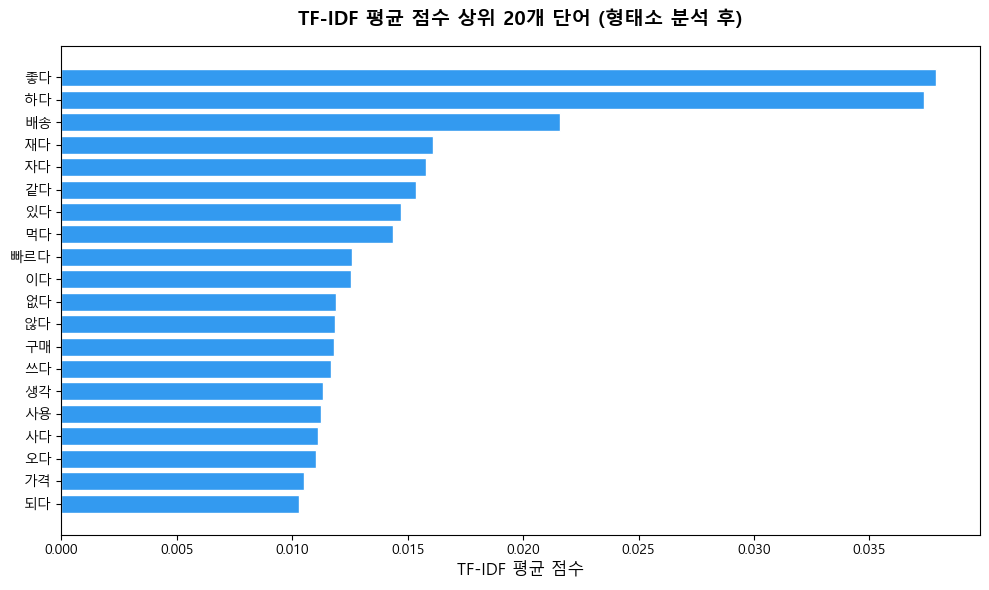

저장 완료 ✅


In [19]:
# TF-IDF 상위 단어 확인
feature_names = tfidf.get_feature_names_out()
tfidf_scores  = X_train_tfidf.toarray().mean(axis=0)
top_idx       = tfidf_scores.argsort()[::-1][:20]

top20_words  = [feature_names[i] for i in top_idx]
top20_scores = [tfidf_scores[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20_words[::-1], top20_scores[::-1], color='#339AF0', edgecolor='white')
ax.set_title('TF-IDF 평균 점수 상위 20개 단어 (형태소 분석 후)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('TF-IDF 평균 점수', fontsize=12)
plt.tight_layout()
plt.savefig('../output/06_tfidf_top_words_okt.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 6. 결과 저장

In [20]:
import os
os.makedirs('../data/preprocessed', exist_ok=True)

# TF-IDF 행렬 저장
save_npz('../data/preprocessed/X_train_tfidf.npz', X_train_tfidf)
save_npz('../data/preprocessed/X_test_tfidf.npz',  X_test_tfidf)

# label 저장 (index=True : 원본 행 번호 보존 → 03_supervised에서 올바른 행 선택에 필요)
y_clf_train.to_csv('../data/preprocessed/y_clf_train.csv', index=True)
y_clf_test.to_csv('../data/preprocessed/y_clf_test.csv',   index=True)
y_reg_train.to_csv('../data/preprocessed/y_reg_train.csv', index=True)
y_reg_test.to_csv('../data/preprocessed/y_reg_test.csv',   index=True)

# TF-IDF 벡터라이저 저장
with open('../data/preprocessed/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 정제된 전체 데이터 저장 (형태소 분석 컬럼 포함)
df.to_csv('../data/preprocessed/reviews_clean.csv', index=False, encoding='utf-8-sig')

print('저장 완료 ✅')
print()
print('저장된 파일 목록 :')
for f in os.listdir('../data/preprocessed'):
    print(f'  {f}')

저장 완료 ✅

저장된 파일 목록 :
  reviews_clean.csv
  tfidf_vectorizer.pkl
  X_test_tfidf.npz
  X_train_tfidf.npz
  y_clf_test.csv
  y_clf_train.csv
  y_reg_test.csv
  y_reg_train.csv


---
## ✅ 전처리 완료 요약

| 항목 | 기존 방식 | 형태소 분석 후 |
|---|---|---|
| 단어 분리 | 공백 기준 | 명사/형용사/동사만 추출 |
| 어간 추출 | ❌ | ✅ (좋아요 → 좋다) |
| 정규화 | ❌ | ✅ (ㅋㅋㅋ → ㅋ) |
| 기대 효과 | - | Recall 개선 기대 |

---